In [1]:
#%pip install --upgrade shap

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as utils_data
from torch.autograd import Variable

import shap

from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import pickle
import json
import os
import warnings
import datetime

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"{torch.cuda.device_count()} GPU(s) available and will be used.\nGPU name(s): {[torch.cuda.get_device_name(n) for n in range(torch.cuda.device_count())]}")
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU.")

1 GPU(s) available and will be used.
GPU name(s): ['Tesla V100-PCIE-16GB']


In [4]:
RANDOM_STATE = 42

In [5]:
class tanh_MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(tanh_MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, output_size)
        
    def forward(self, x):
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        out = self.fc3(x)
        return out

In [6]:
# Instantiate a dataframe on first dataset to get columns
nfl_df = pd.read_csv('../dataset_generators/datasets/0_train_normalized.csv')
# Get normalized columns
y = ['fantasy_points']
X = [col for col in nfl_df.columns if col not in ('player_id'
                                                        , 'player_name'
                                                        , 'player_display_name'
                                                        , 'position','position_group'
                                                        , 'headshot_url'
                                                        , 'season'
                                                        , 'week'
                                                        , 'season_type'
                                                        , 'team'
                                                        , 'opponent_team'
                                                        , 'fantasy_points'
                                                        , 'Unnamed: 0')]
del nfl_df

In [7]:
# The best model is the one below
model = '_100-100_tanh_100_0.0001_norm.pickle'


train_dataset_name = '_train_normalized.csv'
test_dataset_name = '_test_normalized.csv'

all_shap_values = []
all_inputs = []

# Iterate over all 5 versions of the model that were trained on the KFold cross validation sets
for n in range(5):
    # Load the model    
    model_name = f'../model_generators/mlp/models/{n}{model}'
    with open(model_name, 'rb') as f:
        #print(model)
        mlp = pickle.load(f)
        mlp.eval()
    # Get the scaler
    train_data_df = pd.read_csv(f'../dataset_generators/datasets/{n}{train_dataset_name}')
    test_data_df = pd.read_csv(f'../dataset_generators/datasets/{n}{test_dataset_name}')
    new_train_df_x = train_data_df[X]
    new_test_df_x = test_data_df[X]
    def model_wrapper(x_np):
        X_tensor = torch.tensor(x_np, dtype=torch.float32).to(device)
        with torch.no_grad():
            return mlp(X_tensor).cpu().numpy()
    
    explainer = shap.Explainer(model_wrapper, new_train_df_x.values)
    shap_vals = explainer(new_test_df_x)
    all_shap_values.append(shap_vals.values)
    all_inputs.append(new_test_df_x)

PermutationExplainer explainer: 12195it [02:51, 68.36it/s]                           
PermutationExplainer explainer: 12195it [02:53, 66.32it/s]                           
PermutationExplainer explainer: 12195it [02:53, 66.07it/s]                           
PermutationExplainer explainer: 12195it [02:55, 65.69it/s]                           
PermutationExplainer explainer: 12194it [02:58, 64.58it/s]                           


In [8]:
shap_values_all = np.concatenate(all_shap_values, axis=0)
inputs_all = np.concatenate(all_inputs, axis=0)

In [9]:
y_vals = []
for n in range(5):
    test_data_df = pd.read_csv(f'../dataset_generators/datasets/{n}{test_dataset_name}')
    new_test_df_y = test_data_df[y]
    y_vals.append(new_test_df_y.values)

y_vals_all = np.concatenate(y_vals, axis=0)

In [10]:
mean_shap = shap_values_all.mean(axis=0)
shap_values_obj = shap.Explanation(values=shap_values_all, data=inputs_all, base_values=np.mean(y_vals_all))

In [11]:
inputs_all_df = pd.DataFrame(inputs_all, columns=X)

/tmp/ipykernel_1730122/1898781091.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_obj, inputs_all_df)


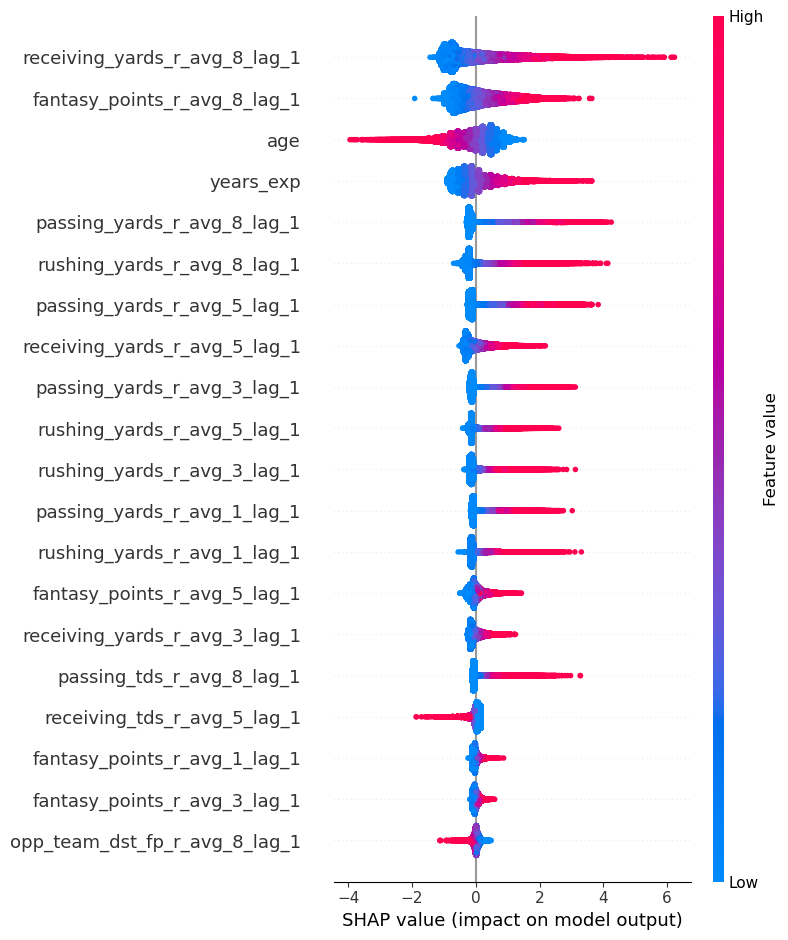

In [12]:
shap.summary_plot(shap_values_obj, inputs_all_df)